# 🎬 Ders Girişi: “Görsel ve Metni Aynı Dünyaya Nasıl Getiririz?”

Bugün hayatımızdaki birçok sistem hem görseli hem metni aynı anda anlıyor:

- 📸 Fotoğraftaki nesneyi bulup açıklama yazan uygulamalar  
- 🛒 Ürün fotoğrafını tanıyıp internetteki açıklamalarla eşleştiren sistemler  
- 🐶 Bir görseli yükleyince “bu hangi hayvan?” diye cevap veren chatbot’lar  
- 🤖 Multimodal modeller: **GPT-4V, LLaVA, CLIP, BLIP-2…**

Bu sistemlerin hepsinin içinde şu temel ihtiyaç vardır:

> **Bir görüntü ile bir cümlenin, birbirini anlayabileceği ortak bir temsil bulmak.**

---

## ⚠️ Ama burada büyük bir sorun ortaya çıkıyor:

### 🖼️ Görüntüler → *piksellerden oluşan dev matrisler*  
### 📝 Metinler → *token dizilerinden oluşan tamamen farklı bir yapı*  

Bu iki bilgi türü **doğal olarak birbiriyle uyumsuzdur**:

- Ne boyutları aynı  
- Ne formatları  
- Ne matematiksel yapıları  

Birisi **RGB piksel değerlerinden**,  
diğeri **“a small brown dog”** gibi kelime token’larından oluşur.

---

## ❓ Peki bir sistem bu soruları nasıl cevaplar?

> **“Bu fotoğraf, bu cümleyi anlatıyor mu?”**

veya

> **“Bu metin hangi görsele daha yakın?”**

---

## 🔍 İşte multimodal yapay zekâ tam burada devreye girer.

Bu dersin ilk konusu tam olarak şunu anlamaktır:

> **Görüntü ve metni matematiksel olarak “ortak bir dile” nasıl çeviririz?**

Bunun için önce şu soruya bakacağız:

# 📘 1. Neden Ortak Bir Uzaya İhtiyaç Var?

## 🔍 Derin ve sezgisel açıklama

Görsel–dil modellerinin kalbinde şu soru vardır:

> **📌 Görüntü ile metni nasıl “aynı dilde konuşturacağız?”**

Çünkü görüntüler ve metinler **tamamen farklı matematiksel yapılara** sahiptir:

---

### 🖼️ **Görüntü → Piksel Matrisi**

Bir görüntü, sayılardan oluşan bir matristir:

- Örneğin: **224 × 224 × 3**
- Her piksel 0–255 arasında RGB değerlerine sahiptir.

Matematiksel olarak bu bir *tensor’dür*:
$$
\text{Image} \in \mathbb{R}^{224 \times 224 \times 3}
$$

---

### 📝 **Metin → Token Dizisi**

Metin ise kelime ya da alt-kelime token’larına dönüştürülür:

Örn:
"A small brown dog"

Tokenizer bunu alt-kelimelere böler ve her birine bir ID verir:
→ [101, 2456, 4321, 3890, 102]


Burada:

- **101** → `[CLS]` token ID’si  
- **102** → `[SEP]` token ID’si  
- **2456, 4321, 3890** → cümledeki kelimelerin sözlükteki karşılıkları


Bu da tamamen farklı bir yapı:
$$
\text{Text} \in \mathbb{Z}^{L}
$$

---

## 💡 Peki problem ne?

Görüntü matrisi ile token dizisini **doğrudan** karşılaştıramayız.

Çünkü:

- Biri 3 boyutlu sürekli değerler (pikseller),
- Diğeri 1 boyutlu ayrık indeksler (token ID’leri).

Transformer ise şöyle der:

> **“Ben dizilerle çalışırım.  
> Bana vektör ver, hepsinin boyutu aynı olsun.”**

---
## 🎯 Çözüm: Her Şeyi Vektör Haline Getirmek

Bu nedenle hem görüntü hem metin **aynı boyutta bir embedding vektörüne** dönüştürülür.

### 🧩 Görüntü → Görsel Encoder → **D boyutlu embedding**

$$
\text{image}\_\text{emb} \in \mathbb{R}^D
$$

### 🧩 Metin → Metin Encoder → **D boyutlu embedding**

$$
\text{text}\_\text{emb} \in \mathbb{R}^D
$$

---

## ❤️ Neden Aynı Boyut?

Çünkü iki embedding ancak **aynı uzayda** karşılaştırılabilir.

Örneğin:

- **Dot product**
- **Cosine similarity**
- **Euclidean distance**

Bu sayede şu hesaplanabilir:

$$\text{sim}(\text{image}\_\text{emb},\ \text{text}\_\text{emb})$$

Bu değer **yüksekse** 👉 görsel ile metin **birbirini anlatıyor** demektir.

---


## ✨ Özet

| Veri tipi | Ham format | Encoder sonrası |
|----------|------------|----------------|
| Görüntü | 224×224×3 piksel matrisi | D boyutlu vektör |
| Metin | Token ID dizisi | D boyutlu vektör |
| Neden? | Farklı formatlar | **Aynı uzayda karşılaştırmak için** |

Bu ortak uzay yaklaşımı, CLIP gibi modellerin temelidir.

🔧 Kullanılan cihaz: cpu


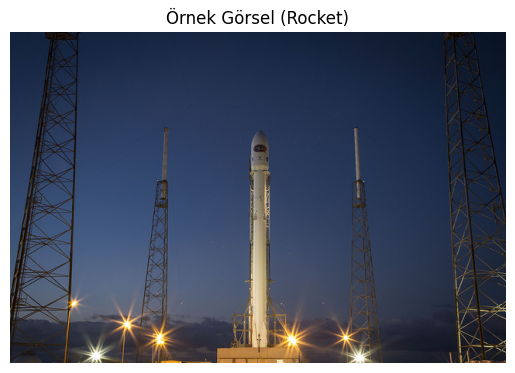

📝 Metin listesi:
  - a rocket launching into the sky
  - a satellite in space
  - a car driving on the road
  - an airplane flying above the clouds
  - a lighthouse near the sea

🔢 Vektör Şekilleri:
Görsel embedding shape : torch.Size([1, 512])
Metin  embedding shape : torch.Size([5, 512])

📏 Ortak embedding boyutu (D): 512

🔍 Görsel embedding [ilk 10 değer]:
tensor([ 0.0517,  0.1837,  0.0505,  0.3596, -0.2339,  0.3353, -0.5185, -0.2195,
         0.3577,  0.6325])

🔍 İlk metnin embedding'i [ilk 10 değer]:
tensor([-0.1427,  0.0322, -0.0373,  0.0323,  0.0970,  0.1435, -0.2967, -0.7816,
        -0.1848,  0.1033])

📐 Cosine Similarity Sonuçları (görsel ↔ her metin):

sim(image_emb, text_emb[1]): 0.2536  |  "a satellite in space"
sim(image_emb, text_emb[0]): 0.2520  |  "a rocket launching into the sky"
sim(image_emb, text_emb[4]): 0.1882  |  "a lighthouse near the sea"
sim(image_emb, text_emb[2]): 0.1551  |  "a car driving on the road"
sim(image_emb, text_emb[3]): 0.1546  |  "an airplane fl

In [ ]:
# ============================================
# 📘 Görsel ve Metni Ortak Uzayda Vektörleştirme
# (CLIP ile basit ama öğretici demo)
# ============================================

# 🔽 Gerekli paketleri yüklüyoruz (sadece ilk çalıştırmada gerekir)
!pip -q install transformers torchvision sentencepiece

import torch
from transformers import CLIPModel, CLIPProcessor
from skimage import data
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F

# -----------------------------
# 0) Cihaz seçimi (GPU varsa onu kullan)
# -----------------------------
# Eğer ortamda CUDA (GPU) varsa onu, yoksa CPU'yu kullan
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🔧 Kullanılan cihaz: {device}")

# -----------------------------
# 1) Örnek görseli hazırla
# -----------------------------
# skimage'in içindeki hazır "rocket" görselini alıyoruz (NumPy array)
img_np = data.rocket()             # [H, W, 3] uint8
# NumPy array'i PIL Image'e çeviriyoruz (CLIP processor PIL bekliyor)
image  = Image.fromarray(img_np)

# Görseli ekrana çizdir
plt.imshow(image)
plt.title("Örnek Görsel (Rocket)")
plt.axis("off")
plt.show()

# -----------------------------
# 2) Birden fazla metin (caption) tanımla
# -----------------------------
# Aynı görsel için farklı olası açıklamalar (caption) yazıyoruz
texts = [
    "a rocket launching into the sky",   # doğruya çok yakın (yüksek benzerlik bekliyoruz)
    "a satellite in space",              # kısmen ilgili
    "a car driving on the road",         # alakasız
    "an airplane flying above the clouds",
    "a lighthouse near the sea"
]

print("📝 Metin listesi:")
for t in texts:
    print("  -", t)

# -----------------------------
# 3) CLIP model ve işlemciyi yükle
# -----------------------------
# openai/clip-vit-base-patch32: ViT tabanlı CLIP modeli
model_name = "openai/clip-vit-base-patch32"

# Modeli indir ve seçtiğimiz cihaza (CPU/GPU) taşı
model     = CLIPModel.from_pretrained(model_name).to(device)

# CLIPProcessor hem görseli hem metni uygun formata (tensor/token) sokuyor
processor = CLIPProcessor.from_pretrained(model_name)

# İnference moduna alıyoruz (eğitim yapmıyoruz, sadece tahmin)
model.eval()

# -----------------------------
# 4) Görsel ve metni vektörleştir
# -----------------------------
# Processor:
#  - Görsel için: yeniden boyutlandırma, normalize vs.
#  - Metin için: tokenizasyon, padding vs.
inputs = processor(
    text=texts,           # birden fazla metin → (N adet caption)
    images=[image],       # tek görsel (liste içinde olmak zorunda)
    return_tensors="pt",  # PyTorch tensörleri döndür
    padding=True          # metinleri aynı uzunluğa getir (pad)
)

# Çıkan tüm tensörleri (input_ids, attention_mask, pixel_values, vs.)
# seçtiğimiz cihaza (CPU/GPU) taşıyoruz.
for k in inputs:
    inputs[k] = inputs[k].to(device)

# Gradient hesaplamaya gerek yok, sadece forward yapacağız
with torch.no_grad():
    # Görsel embedding'ini hesapla → (1, D)
    img_features  = model.get_image_features(
        pixel_values=inputs["pixel_values"]
    )
    # Metin embedding'lerini hesapla → (N, D)
    text_features = model.get_text_features(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    )

# -----------------------------
# 5) Vektör şekilleri ve ilk değerler
# -----------------------------
print("\n🔢 Vektör Şekilleri:")
print("Görsel embedding shape :", img_features.shape)   # [1, D]
print("Metin  embedding shape :", text_features.shape)  # [N, D]

# Ortak uzayın boyutu (D): hem görüntü hem metin bu boyutta vektörlere gömülüyor
D = img_features.shape[-1]
print(f"\n📏 Ortak embedding boyutu (D): {D}")

# Bir fikir vermesi için vektörlerin ilk 10 elemanını yazdırıyoruz
print("\n🔍 Görsel embedding [ilk 10 değer]:")
print(img_features[0, :10].cpu())

print("\n🔍 İlk metnin embedding'i [ilk 10 değer]:")
print(text_features[0, :10].cpu())

# -----------------------------
# 6) Cosine similarity hesapla (görsel ↔ tüm metinler)
# -----------------------------
# Teorik olarak CLIP zaten L2 normalize edilmiş vektör döndürür,
# ama cosine similarity mantığını göstermek için biz de normalize ediyoruz.
img_norm  = F.normalize(img_features,  p=2, dim=-1)   # [1, D]
txt_norm  = F.normalize(text_features, p=2, dim=-1)   # [N, D]

# Cosine similarity:
# (1, D) @ (D, N) → (1, N) → her metin için bir benzerlik skoru
cos_sims = (img_norm @ txt_norm.T).squeeze(0).cpu()   # [N]

# Sonuçları büyükten küçüğe sırala
sorted_indices = torch.argsort(cos_sims, descending=True)

print("\n📐 Cosine Similarity Sonuçları (görsel ↔ her metin):\n")
for idx in sorted_indices:
    i = idx.item()
    # Her metin için similarity değeri ve metnin kendisini yazdır
    print(f"sim(image_emb, text_emb[{i}]): {cos_sims[i]:.4f}  |  \"{texts[i]}\"")

# -----------------------------
# 7) Yorumlayıcı açıklama
# -----------------------------
# En yüksek ve en düşük benzerlik alan caption'ları bul
best_idx = sorted_indices[0].item()
worst_idx = sorted_indices[-1].item()

print("\n✅ En yüksek benzerlik:")
print(f"  → {cos_sims[best_idx]:.4f}  |  \"{texts[best_idx]}\"")

print("\n⚠️ En düşük benzerlik:")
print(f"  → {cos_sims[worst_idx]:.4f}  |  \"{texts[worst_idx]}\"")

print("""
📌 Yorum:
- Cosine similarity 1'e ne kadar yakınsa, görsel ve metin vektörleri aynı yöne o kadar çok bakıyor demektir.
- Yani D boyutlu ortak uzayda, roket görseline en yakın caption en yüksek similarity değerine sahip olur.
- Beklenti: "a rocket launching into the sky" benzerliği en yüksek,
  "a car driving on the road" gibi alakasız caption'lar en düşük olmalıdır.
""")

# 📘 Cosine Similarity — “İki vektör aynı yöne bakıyor mu?”

Cosine similarity, Vision–Language modellerinin görsel ve metin embedding’lerini karşılaştırırken kullandığı temel ölçüdür.  
Asıl amaç şudur:

> **Görsel embedding ile metin embedding’i aynı anlamı taşıyor mu?**

Bu, iki vektörün **yönü** üzerinden ölçülür.

---

## 🧮 1. Matematiksel Tanım

İki vektör \( a \) ve \( b \) için cosine similarity:

$$
\text{cos_sim}(a,b) = \frac{a \cdot b}{\|a\|\|b\|}
$$

-  $a \cdot b$ : dot product
- $|a|$, $|b|$: L2 normu (vektör uzunluğu)

---

## 🎨 3. Sezgisel Açıklama — “Vektörler uzayda ok gibidir”

Cosine similarity’nin en sezgisel açıklaması şudur:

> **Bir embedding uzayını, içindeki her vektörü de bir pusula oku gibi düşünün.  
> Cosine similarity, bu iki okun aynı yöne bakıp bakmadığını ölçer.**

### 🧭 2D Vektör Uzayı Örneği

Aşağıdaki iki vektörü düşünelim:

- A = (2, 2)
- B = (8, 8)

Bu vektörlerin ikisi de *2D düzlemde aynı doğrultuda* yer alır:

- Her ikisi de **45°** açıyla yukarı-sağa doğru gider.
- Uzunlukları farklı olsa bile **yönleri aynıdır**.

# 📘 Contrastive Learning (Karşıt Öğrenme)
Vision–Language modellerinin en kritik gücü, yalnızca embedding üretmesi değil,  
**doğru görsel–metin eşleşmelerini yaklaşmaya zorlayan, yanlış eşleşmeleri iten** bir eğitim yöntemi kullanmasıdır.

Bu yönteme **Contrastive Learning** denir.

---

# 🧩 1. Temel Fikir

Her görüntü–metin çifti için modelin bildiği tek bir gerçek vardır:

- Bu görselin **tek bir doğru caption’ı** vardır.  
- Bu görsele ait olmayan **diğer tüm caption’lar yanlıştır**.

Bu nedenle eğitim sırasında CLIP şöyle davranır:

### ✔ Pozitif çift (doğru eşleşme)
Görsel ↔ cümlenin gerçekten anlattığı şey  
Örnek: (köpek görseli ↔ "a small brown dog")

### ✖ Negatif çiftler (yanlış eşleşme)
Görsel ↔ onunla ilgisi olmayan tüm diğer cümleler  
Örnek: (köpek görseli ↔ "a red car")

**Modelin hedefi:**

> 🔼 Pozitif eşleşmelerin benzerliğini artır  
> 🔽 Negatif eşleşmelerin benzerliğini azalt

---

# 🧮 2. InfoNCE / Contrastive Loss  

Önce notasyonları açıkça tanımlayalım:

Bir **batch**’te $\mathbf{N}$ tane görsel ve $\mathbf{N}$ tane caption olsun:

* **Görsel Embedding’leri:**
    $$
    i_1, i_2, \dots, i_N
    $$

* **Metin Embedding’leri:**
    $$
    t_1, t_2, \dots, t_N
    $$


### Doğru Eşleşme (Ground Truth)

Her görsel $\mathbf{i_k}$, kendi caption’ı $\mathbf{t_k}$ ile eşleşir.

Bu nedenle, **k. görsel ↔ k. caption** pozitif çifttir.  
Tüm diğer eşleşmeler negatif çift olur.

---

# 🔢 Skor Matrisi $ S_{ij} $

Eğitimde kullanılan skor matrisi  S,  
her görsel–metin çifti arasındaki **cosine similarity** ile oluşturulur:

$$
S_{ij} = \text{cos_sim}(i_j,\ t_i)
$$

CLIP embedding’leri **L2 normalize** ettiği için, cosine similarity = dot product:

$$
S_{ij} = i_j \cdot t_i
$$


Bu matris N×N boyutundadır:

- Diyagonal: $ S_{11}, S_{22}, …, S_{NN} $ → **doğru eşleşmeler**
- Diyagonal dışı: diğer tüm elemanlar → **yanlış eşleşmeler**

---

## 🔸 Metinden → Görüntüye yönlü loss

Metin $ t_i$’nin doğru eşleşmesi görsel $ i_i $’dir.

Bu nedenle softmax şu şekilde kurulur:

$$
\mathcal{L}_{\text{text→image}} =
-\frac{1}{N}
\sum_{i=1}^{N}
\log
\frac{\exp(S_{ii}/\tau)}
{\sum_{j=1}^{N} \exp(S_{ij}/\tau)}
$$

Burada:
- $ S_{ii} $: caption $ t_i $ ↔ görsel $ i_i $ doğru eşleşme skoru  
- Paydadaki diğer terimler: caption $ t_i $’nin **yanlış** eşleşme skorları

---

## 🔸 Görüntüden → Metne yönlü loss

Bu defa görsel $ i_i $’nin doğru eşleşmesi caption $ t_i $’dir.

Bu nedenle:

$$
\mathcal{L}_{\text{image→text}} =
-\frac{1}{N}
\sum_{i=1}^{N}
\log
\frac{\exp(S_{ii}/\tau)}
{\sum_{j=1}^{N} \exp(S_{ji}/\tau)}
$$

Bu kez softmax satır değil, **sütun** üzerinden kurulmuştur.

---

## 🔸 Toplam Loss (CLIP’in optimize ettiği)

$$
\mathcal{L} =
\frac{1}{2}
\left(
\mathcal{L}_{\text{text→image}}
+
\mathcal{L}_{\text{image→text}}
\right)
$$

Burada:

* $ S_{ii} $ doğru görsel–metin eşleşmesinin similarity skoru  
* $ S_{ij} $ yanlış eşleşme skorları  
* $ \tau $ (temperature): softmax dağılımını keskinleştirir  

---

# ✔ Özetle:

- $ i_k $ **k. görsel embedding’i**  
- $ t_k $ **k. caption embedding’i**  
- $ S_{ij} = \text{similarity}(i_j, t_i) $ **skor matrisi**  
- InfoNCE loss: doğru eşleşmeleri ↑ yükseltir, yanlışları ↓ bastırır  

Bu mekanizma CLIP’in ortak uzayı öğrenmesini sağlar.

Her şey **InfoNCE loss’un zorladığı hizalamada** gerçekleşir.


## 📌 Örnekle Açalım (En Anlaşılır Kısım)

Aşağıdaki senaryoda bir caption $ t_i $ için tüm görsellerle similarity skorlarını düşünelim:

### 🔹 Görsel–Metin Similarity Skorları (caption $ t_i $ için)

| Görsel | Similarity |
|--------|------------|
| ✅ Doğru görsel | **0.60** |
| ❌ Yanlış görsel 1 | 0.58 |
| ❌ Yanlış görsel 2 | 0.55 |
| ❌ Yanlış görsel 3 | 0.57 |

Görüldüğü gibi:

- Doğru eşleşme skoru: **0.60**
- Yanlış eşleşmeler: **0.55–0.58** arası (çok yakın!)

Bu durumda softmax şöyle hesaplanır:

Softmax formülü:

$$
P =
\frac{e^{0.60}}
{e^{0.60} + e^{0.58} + e^{0.55} + e^{0.57}}
$$

### ✨ Adım Adım Hesaplama

$$
e^{0.60} = 1.8221188
$$
$$
e^{0.58} = 1.786056
$$
$$
e^{0.55} = 1.733253
$$
$$
e^{0.57} = 1.770243
$$

Toplam:

$$
1.8221188 + 1.786056 + 1.733253 + 1.770243 = 7.11167
$$

Softmax sonucu:

$$
P = \frac{1.8221188}{7.11167} = 0.2561
$$

---

### ✅ **Sonuç: P ≈ 0.256**

Doğru eşleşme skorunun 0.60 olmasına rağmen,  
yanlış eşleşmeler çok yakın olduğu için softmax doğru sınıfa **yalnızca %25.6** olasılık veriyor.

### 🔍 Bu olasılık **düşük çıkar**, çünkü:

- Yanlış eşleşmelerin skorları **doğruya çok yakın**
- Model **emin değil**: “Bu caption hangi görsele ait?”

### Sonuç:

- **Loss yüksek çıkar** → model cezalandırılır  
- Model şu iki şeyi yapmaya zorlanır:
  - $ S_{ii} $ (doğru similarity) → **daha da yükselt**
  - Yanlış similarity’ler $ S_{ij} $ → **bastır, düşür**

---

## 📌 İkinci Senaryo: Çok Net Bir Doğruluk

### 🔢 Verilen Similarity Değerleri

| Görsel | Similarity |
|--------|------------|
| ✅ Doğru görsel | **0.90** |
| ❌ Yanlış görsel 1 | 0.10 |
| ❌ Yanlış görsel 2 | 0.12 |
| ❌ Yanlış görsel 3 | 0.15 |

Softmax:

$$
P =
\frac{e^{0.90}}
{e^{0.90}+e^{0.10}+e^{0.12}+e^{0.15}}
$$

### ✨ Adım Adım Hesaplama

$$
e^{0.90} = 2.459603
$$
$$
e^{0.10} = 1.105170
$$
$$
e^{0.12} = 1.127497
$$
$$
e^{0.15} = 1.161834
$$

Toplam:

$$
2.459603 + 1.105170 + 1.127497 + 1.161834
= 5.854104
$$

Softmax sonucu:

$$
P = \frac{2.459603}{5.854104}
= 0.4202
$$

---

### ✅ **Sonuç: P ≈ 0.42**

Doğru similarity değeri **0.90** olsa bile,  
yanlış similarity değerleri hâlâ pozitif olduğu için softmax doğru sınıfa **yaklaşık %42** güven veriyor.

> Softmax yalnızca “göreceli” farklara bakar;  
> rakipler çok küçük olmadıkça $ P \approx 1.0 $ olmaz.



Yani:

- $ P \approx 1.0 $
- Loss ≈ **0**
- Model **ödüllendirilir**

---

## 🚀 Asıl Amaç: Göreceli Doğruluk

Bu bölümleme sayesinde model şunu öğrenir:

> **“Doğru embedding sadece yüksek olduğu için değil,  
> yanlış embedding’lerden bariz şekilde daha yüksek olduğu için doğrudur.”**

Bu yüzden model:

- $ S_{ii} $ → **maksimuma çıkarır**
- $ S_{ij} $ (j ≠ i) → **minimuma iter**
- Aradaki farkı → **oldukça açmaya çalışır**

🔧 Kullanılan cihaz: cpu


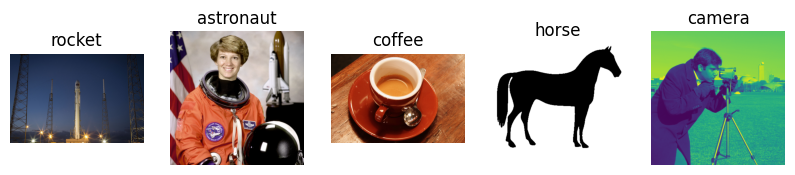

📝 Kullanılan metinler:
  - a rocket launching into the sky
  - an astronaut in a space suit
  - a cup of coffee on a table
  - a horse standing on the grass
  - an old film camera on a tripod

📏 Embedding boyutları:
Görseller: torch.Size([5, 512])
Metinler : torch.Size([5, 512])

🔢 Similarity Matrix (S):
tensor([[0.2520, 0.2085, 0.1406, 0.1708, 0.1626],
        [0.1718, 0.2795, 0.1488, 0.1475, 0.1416],
        [0.1280, 0.1542, 0.2918, 0.1312, 0.1587],
        [0.1465, 0.1905, 0.1923, 0.3093, 0.1705],
        [0.2044, 0.1802, 0.1772, 0.1876, 0.2887]])

🎯 Her görsel için en yüksek similarity hangi caption'a ait?
  Görsel 0 (rocket): en yüksek sim = 0.2520  ->  "a rocket launching into the sky"
  Görsel 1 (astronaut): en yüksek sim = 0.2795  ->  "an astronaut in a space suit"
  Görsel 2 (coffee): en yüksek sim = 0.2918  ->  "a cup of coffee on a table"
  Görsel 3 (horse): en yüksek sim = 0.3093  ->  "a horse standing on the grass"
  Görsel 4 (camera): en yüksek sim = 0.2887  ->  "an old f

In [ ]:
# ============================================
# 📘 5 Farklı Görsel + 5 Caption ile
# Contrastive Learning / InfoNCE Demo
# ============================================

# Bu demoda:
# - 5 farklı görsel (rocket, astronaut, coffee, horse, camera)
# - 5 farklı caption (her biri doğru görseli tarif ediyor)
# kullanarak CLIP ile:
#   1) Görsel ve metin embedding'lerini çıkaracağız
#   2) 5x5 similarity matrix oluşturacağız
#   3) InfoNCE tarzı contrastive loss hesaplayacağız

!pip -q install transformers torchvision sentencepiece scikit-image

import torch
import torch.nn.functional as F
from transformers import CLIPModel, CLIPProcessor
from skimage import data
from PIL import Image
import matplotlib.pyplot as plt

# -----------------------------
# 0) Cihaz seçimi
# -----------------------------
# GPU varsa "cuda", yoksa "cpu" ile devam ediyoruz.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🔧 Kullanılan cihaz: {device}")

# -----------------------------
# 1) 5 farklı örnek görseli hazırla
# -----------------------------
# skimage.data içindeki hazır görselleri kullanıyoruz.
# Bunlar NumPy array formatında geliyor (H, W, 3).
img_list_np = [
    data.rocket(),     # 0: roket
    data.astronaut(),  # 1: astronot
    data.coffee(),     # 2: kahve fincanı
    data.horse(),      # 3: at
    data.camera()      # 4: eski fotoğraf makinesi
]

# CLIPProcessor, PIL Image beklediği için NumPy → PIL çeviriyoruz.
images = [Image.fromarray(x) for x in img_list_np]

# Sadece görsel başlıkları (plot’ta altına yazmak için)
titles = ["rocket", "astronaut", "coffee", "horse", "camera"]

# 5 görseli tek satırlı bir grid içinde gösterelim
plt.figure(figsize=(10, 2))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
plt.show()

# -----------------------------
# 2) Bu görsellere uygun 5 caption yazalım
# -----------------------------
# Her görseli tarif eden bir cümle:
texts = [
    "a rocket launching into the sky",        # rocket
    "an astronaut in a space suit",           # astronaut
    "a cup of coffee on a table",             # coffee
    "a horse standing on the grass",          # horse
    "an old film camera on a tripod"          # camera
]

print("📝 Kullanılan metinler:")
for t in texts:
    print("  -", t)

# -----------------------------
# 3) CLIP modelini ve processor'ü yükle
# -----------------------------
# openai/clip-vit-base-patch32: Vision Transformer (ViT) tabanlı bir CLIP modeli.
model_name = "openai/clip-vit-base-patch32"

# Modeli indir ve seçtiğimiz cihaza (CPU/GPU) taşı.
model = CLIPModel.from_pretrained(model_name).to(device)

# CLIPProcessor:
# - Görseller için: resize, center crop, normalize gibi işlemler
# - Metin için: tokenization, padding, attention mask üretimi
processor = CLIPProcessor.from_pretrained(model_name)

# Sadece inference yapacağımız için eval moduna alıyoruz.
model.eval()

# -----------------------------
# 4) Görseller + metinler için embedding'leri üret
# -----------------------------
# Processor, hem text hem image'i tek seferde işleyebiliyor.
inputs = processor(
    text=texts,       # 5 adet metin
    images=images,    # 5 adet görsel
    return_tensors="pt",
    padding=True      # metinleri aynı uzunluğa getir (pad)
)

# Üretilen tüm tensörleri cihaza taşıyoruz.
for k in inputs:
    inputs[k] = inputs[k].to(device)

# Gradient hesabı yok, sadece forward → no_grad()
with torch.no_grad():
    # Görsel embedding'leri (5, D) boyutunda
    # Burada her satır bir görselin embedding'i.
    img_emb = model.get_image_features(inputs["pixel_values"])      # (5, D)

    # Metin embedding'leri (5, D) boyutunda
    # Burada her satır bir caption'ın embedding'i.
    txt_emb = model.get_text_features(
        inputs["input_ids"],
        inputs["attention_mask"]
    )  # (5, D)

# Cosine similarity için L2 normalize ediyoruz.
# (CLIP zaten normalize edilmiş vektörlere yakın üretiyor ama
# eğitim mantığını göstermek için burada açıkça normalize ediyoruz.)
img_emb = F.normalize(img_emb, dim=-1)   # (5, D)
txt_emb = F.normalize(txt_emb, dim=-1)   # (5, D)

print("\n📏 Embedding boyutları:")
print("Görseller:", img_emb.shape)  # (5, D)
print("Metinler :", txt_emb.shape)  # (5, D)

# -----------------------------
# 5) Similarity matrix (5x5)
# -----------------------------
# img_emb @ txt_emb.T:
#   - img_emb:   (5, D)
#   - txt_emb.T: (D, 5)
# Sonuç: S (5, 5)
#   - S[i, j] → i. görsel ile j. caption arasındaki cosine benzerliği
S = img_emb @ txt_emb.T    # (5, 5)

print("\n🔢 Similarity Matrix (S):")
print(S.cpu())

# Her satır bir görseli temsil ediyor:
# Satırdaki en büyük değer → o görsele en uygun caption.
print("\n🎯 Her görsel için en yüksek similarity hangi caption'a ait?")
for i in range(5):
    row = S[i]
    # torch.argmax: en büyük değerin index'ini döndürür.
    best_j = torch.argmax(row).item()
    print(
        f"  Görsel {i} ({titles[i]}): "
        f"en yüksek sim = {row[best_j]:.4f}  ->  \"{texts[best_j]}\""
    )

# -----------------------------
# 6) InfoNCE Contrastive Loss
# -----------------------------
# Burada mini-batch boyutumuz N = 5.
# InfoNCE mantığı:
#   - Her görsel için "doğru caption" pozitiftir (i = j).
#   - Diğer 4 caption negatiftir (i ≠ j).
#   - Cross-entropy, doğru eşleşmeye (diyagonale) yüksek skor,
#     yanlış eşleşmelere düşük skor vermek ister.

# τ (tau) = sıcaklık parametresi
# Skorları (logit) daha keskin veya yumuşak hale getirir.
tau = 0.07

# Similarity matrix'i sıcaklıkla ölçekliyoruz.
S_scaled = S / tau  # (5, 5)

# labels: her satır için doğru sınıf indexi
# - Görsel 0 için doğru caption indexi 0
# - Görsel 1 için doğru caption indexi 1
# ...
labels = torch.arange(5).to(device)   # tensor([0,1,2,3,4])

# image→text yönlü loss:
#   - Her satır (i. görsel) bir "sample"
#   - S_scaled[i] içindeki 5 skor → class skorları
#   - labels[i] = i → doğru caption indexi
loss_img2txt = F.cross_entropy(S_scaled, labels)

# text→image yönlü loss:
#   - Bu kez her caption bir "sample"
#   - S_scaled.T[j] içinde 5 skor → caption j için tüm görseller
#   - labels[j] = j → doğru görsel indexi
loss_txt2img = F.cross_entropy(S_scaled.T, labels)

# İki yönlü loss'un ortalamasını alıyoruz (CLIP eğitiminde yapılan şey).
loss = (loss_img2txt + loss_txt2img) / 2

print("\n📉 Loss (image→text):", loss_img2txt.item())
print("📉 Loss (text→image):", loss_txt2img.item())
print("📉 Ortalama Contrastive Loss:", loss.item())

print("""
📌 Yorum:
- Bu örnekte 5 FARKLI görsel ve 5 FARKLI caption kullandık.
- Similarity matrix S:
    • S[i, j] → i. görsel ile j. caption'ın kosinüs benzerliği.
- Diyagonal elemanlar S[0,0], S[1,1], ..., S[4,4] → DOĞRU eşleşmeler.
- Cross-entropy (InfoNCE):
    • Doğru eşleşmelerin (diyagonal) skorlarını büyütmeye,
    • Yanlış eşleşmelerin (i≠j) skorlarını küçültmeye çalışır.
- Eğitim sürdükçe:
    • Diyagonaldeki değerler 1'e yaklaşır,
    • Diğer hücreler 0'a doğru bastırılır,
    • Böylece model doğru görsel–metin eşleşmelerini
      ortak embedding uzayında birbirine yaklaştırmayı öğrenir.
""")


![Diyagonal Matris](https://miro.medium.com/v2/resize:fit:4800/format:webp/1*0VnrYSHrtaMr7edzSLbPvg.png)

![Diyagonal Matris](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*YTXxe6POMEEHcgOVi0Ic-Q.png)

![Diyagonal Matris](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*TkE7NvsPMvOceZGpLhC9vg.png)

## 📚 Kaynak

**vom Lehn, Frederik.**  
*Understanding CLIP for Vision-Language Models.*  
Self-Supervised Learning (Medium), 29 September 2024.  
https://medium.com/self-supervised-learning/understanding-clip-for-vision-language-models-43b700a4aa2b


# 🎯 Projection Heads: Görsel ve Metni Aynı Boyuta Getiren Köprü

---

## 🔍 1. Neden Projection Head’e İhtiyaç Var?

Görsel ve metin encoder’ları doğaları gereği farklı embedding boyutları üretir:

| Encoder | Boyut | Açıklama |
|--------|-------|----------|
| **ViT-B/32** | 768 | Görüntü patch embedding boyutu |
| **Text Transformer** | 512 | Token embedding boyutu |

Bu durumda:

$$
\text{image_emb} \in \mathbb{R}^{768},
\quad
\text{text_emb} \in \mathbb{R}^{512}
$$

Bu iki vektör arasında:

- cosine similarity  
- dot product  
- InfoNCE loss  

hesaplanamaz, çünkü boyutlar eşit değildir.

---

### 🎯 CLIP’in temel prensibi:

**Görsel ve metin embedding’leri ortak bir D boyutlu uzayda olmalıdır.**

Dolayısıyla zorunlu dönüşümler:

$$
768 \rightarrow D,
\quad
512 \rightarrow D
$$

Bu dönüşümü yapan katmana **Projection Head** denir.

---

## 🔧 2. Projection Head Nedir?

En basit haliyle doğrusal bir dönüşümdür:

$$
\text{proj} = W x + b
$$

PyTorch karşılığı:

```python
nn.Linear(in_features, out_features)
```

## 🔧 Projection Head Nedir?

Projection head aslında:

- boyut eşitleyen  
- dönüşüm yapan  
- parametre öğrenen  

### Yaygın Projection Head Yapıları

- **Tek Linear katman** (CLIP’in orijinalinde bu)
- **2-layer MLP (Linear → GELU → Linear)**
- Opsiyonel **LayerNorm**
- Opsiyonel **Dropout**

Projection head, **görsel ve metni aynı semantik uzaya taşıyan köprüdür.**

---

## 🧠 3. CLIP’te Projection Head Nasıl Çalışır?

CLIP’te iki farklı projection head bulunur:

### 📷 Görsel Projection Head

$$
z_i = W_i \cdot i_i + b_i
$$

### 📝 Metin Projection Head

$$
z_t = W_t \cdot t_i + b_t
$$

Burada:

- $ i_i $: Image encoder çıkışı (ör. 768 boyut)  
- $ t_i $: Text encoder çıkışı (ör. 512 boyut)  
- $ W_i, W_t $: Projection matrisleri  
- Çıkış embedding boyutu genelde:

$$
D = 512
$$

Sonuç embedding’ler:

$$
z_i,\ z_t \in \mathbb{R}^{D}
$$

Artık:

- cosine similarity uygulanabilir  
- InfoNCE loss hesaplanabilir  
- ortak uzay oluşmuştur  

---

## 🎭 4. Neden 2 Farklı Projection Head Var?

Çünkü görsel ve metin sinyalleri **yapısal olarak farklıdır**:

- Görüntü embedding’leri → *CLS tabanlı*  
- Metin embedding’leri → *EOT tabanlı*  

Bu iki encoder’ın:

- dağılımları  
- varyansları  
- istatistiksel özellikleri  
- geometrik yönelimleri  

birbirinden tamamen farklıdır.

### Tek projection head kullanmak ne yaratır?

- İki modaliteyi aynı kalıba sokar  
- Bu **misalignment (uyumsuz hizalama)** oluşturur  
- Zero-shot accuracy dramatik biçimde düşer  

Bu nedenle CLIP:

- Görsel için ayrı $ W_i $  
- Metin için ayrı $ W_t $  

öğrenir.

---

## ✔ Son Özet

Projection Head:

- Görsel ve metni **aynı boyuta getirir**  
- Ortak bir embedding uzayı oluşturur  
- Cosine similarity’yi mümkün kılar  
- InfoNCE loss’un doğru çalışmasını sağlar  
- Cross-modal alignment’ın temel taşıdır  
- Zero-shot başarının anahtarıdır  

In [ ]:
# ============================
# 📌 TEXT PROJECTION HEAD DEMO
# ============================

!pip -q install transformers sentencepiece

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import CLIPTokenizer, CLIPTextModel

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------
# 1) Metinleri hazırla
# ---------------------
texts = [
    "a rocket launching into the sky",
    "a cute brown dog running",
]

# CLIP text tokenizer + model
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
text_model = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
text_model.eval()

# Tokenize
inputs = tokenizer(texts, return_tensors="pt", padding=True).to(device)

# ---------------------
# 2) Text encoder çıkışı (EOT embedding)
# ---------------------
with torch.no_grad():
    out = text_model(**inputs)
    last_hidden = out.last_hidden_state          # (batch, seq, dim)
    text_emb = last_hidden[torch.arange(len(texts)), inputs["input_ids"].argmax(dim=1)]
    # Bu EOT token embedding’idir

print("📏 Orijinal text embedding shape:", text_emb.shape)

# ---------------------
# 3) Projection head ile boyut eşitle
# ---------------------
proj_txt = nn.Linear(text_emb.size(-1), 512).to(device)
z_txt = proj_txt(text_emb)

print("📏 Projection sonrası shape:", z_txt.shape)

# ---------------------
# 4) Cosine similarity (iki metin arası)
# ---------------------
sim_txt = F.cosine_similarity(z_txt[0:1], z_txt[1:2]).item()
print("\n📐 Cosine similarity (text-text):", sim_txt)


📏 Orijinal text embedding shape: torch.Size([2, 512])
📏 Projection sonrası shape: torch.Size([2, 512])

📐 Cosine similarity (text-text): 0.43693917989730835


In [ ]:
# ============================
# 📌 IMAGE PROJECTION HEAD DEMO
# ============================

!pip -q install transformers sentencepiece torchvision

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import CLIPVisionModel, CLIPProcessor
from PIL import Image
from skimage import data

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------
# 1) Örnek görsel
# ---------------------
img_np = data.rocket()
image = Image.fromarray(img_np)

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
img_model = CLIPVisionModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
img_model.eval()

inputs = processor(images=[image], return_tensors="pt").to(device)

# ---------------------
# 2) Görsel embedding (CLS token)
# ---------------------
with torch.no_grad():
    out = img_model(**inputs)
    img_emb = out.pooler_output  # (1, 768) CLS-like global image embedding

print("📏 Orijinal image embedding shape:", img_emb.shape)

# ---------------------
# 3) Projection head (768 → 512)
# ---------------------
proj_img = nn.Linear(img_emb.size(-1), 512).to(device)
z_img = proj_img(img_emb)

print("📏 Projection sonrası shape:", z_img.shape)

# ---------------------
# 4) Text embedding (aynı önceki gibi alıyoruz)
# ---------------------
from transformers import CLIPTokenizer, CLIPTextModel

tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
text_model = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device)

text = ["a rocket launching into the sky"]
inputs_txt = tokenizer(text, return_tensors="pt").to(device)

with torch.no_grad():
    txt_out = text_model(**inputs_txt)
    txt_emb = txt_out.last_hidden_state[0, inputs_txt["input_ids"].argmax()]  # EOT

proj_txt = nn.Linear(txt_emb.size(-1), 512).to(device)
z_txt = proj_txt(txt_emb.unsqueeze(0))  # (1, 512)

# ---------------------
# 5) Cosine similarity (image ↔ text)
# ---------------------
sim = F.cosine_similarity(z_img, z_txt).item()
print("\n📐 Cosine similarity (image-text):", sim)


📏 Orijinal image embedding shape: torch.Size([1, 768])
📏 Projection sonrası shape: torch.Size([1, 512])

📐 Cosine similarity (image-text): -0.029656413942575455
